# mask + prepare images for AutoProf + run Autoprof

> Optionally mask sources in a Euclid or Mock image prior to ICL measurements.

> Set NaN values to finite value (default 99), as cleaned images, to prep for autoprof

> Run Autoprof on images, using the measurement mask from step one.

> Extract Surface Brightness Profile with measuring median within annuli, and compare to Autoprof resutls.

In [1]:
# | default_exp euclid.mask

In [2]:
# | exporti
import pandas as pd 

import glob
from pathlib import Path
import numpy as np

import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.stats import sigma_clip
from astropy.coordinates import SkyCoord
from astropy.nddata import CCDData

from nicl.mask import (
    create_bcg_mask,
    create_icl_mask,
    create_faint_mask,
    create_object_mask,
)
from nicl.utilities import (
    calc_sb_threshold as _calc_sb_threshold,
    get_pixel_scale,
    sb_to_adu,
)

In [3]:
# | hide

import logging

import matplotlib.pyplot as plt


from nicl.main import configure_logging
from nicl.mask import plot_mask

import importlib.util
import sys
import os
import traceback
from textwrap import dedent

import autoprof
from autoprof import Pipeline 

from photutils.aperture import EllipticalAnnulus, CircularAnnulus
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from scipy.stats import median_abs_deviation

from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import FlatLambdaCDM
h=0.7
cosmo=FlatLambdaCDM(H0=h*100, Om0=0.3)

In [4]:
# | exporti
plt.style.use("nicl.euclid.v1nicl")

### masking is too sensitive to NSIGMA in icl mask


In [35]:
######### Parameters below are being called in create_masks
ICL_NSIGMA = 0.5    
ICL_SMOOTH_SIGMA = 50.0
ICL_BKG_BOX_SIZE = 300
ICL_BKG_FILTER_SIZE = 3
ICL_DILATION_RADIUS = 70.0
ICL_MEDIAN_FILTER = True
REGULAR_DETECTION_PARAMS = {
    "nsigma": 3.0,
    "background": 0.0,
    "smooth_sigma": 1.0,
    "npixels": 5,
    "nlevels": 32,
    "contrast": 0.01,
    "bkg_box_size": 200,
    "bkg_filter_size": 3,
}
REGULAR_GROWTH = 0.5
FAINT_DETECTION_PARAMS = {
    "nsigma": 2.0,
    "smooth_sigma": 1.0,
    "npixels": 5,
    "nlevels": 128,
    "contrast": 0.001,
}
FAINT_GROWTH = 0.25
FAINT_BKG_SIGMA = 50.0
NIR_STACK_BKG_BOX_SIZE = 300
NIR_STACK_BKG_FILTER_SIZE = 3

In [36]:

def calc_sb_threshold(
    z,  # cluster redshift
    filter,  # Euclid filter: VIS, Y, J or H
):
    """Determine the ICL surface brightness threshold for a given redshift and Euclid filter."""
    filter = filter.replace("NIR_", "")
    filter = f"Euclid-{filter}.ecsv"
    return _calc_sb_threshold(z, filter)
    
def create_masks(
    image,  # the image to mask, with bad pixels set to NaN, as a CCDImage or filename
    *,  # the following parameters must be provided as keyword arguments if required
    z=None,  # the cluster redshift for the BCG mask; if None then returned BCG mask is None
    filter=None,  # the filter name for the BCG mask; if None then returned BCG mask is None
    centre_pos=None,  # the position of the BCG/cluster centre; set to False for a non-cluster image
    make_faint_mask=True,  # whether to create a separate object mask in the ICL region
    zeropoint="ZPAB",  # the zeropoint, either as a header keyword or numeric value
):
    """Create BCG, ICL, object and faint masks with default settings for Euclid data.

    These default settings are to be refined.
    """
    if isinstance(image, str):
        image = CCDData.read(image, unit="adu")  # unit does not matter
    # === Bad pixels ===
    badpixel_mask = ~np.isfinite(image)
    # === BCG ===
    if centre_pos is not False and z is not None and filter is not None:
        sb_threshold = calc_sb_threshold(z, filter)
        if isinstance(zeropoint, str):
            zp = image.header[zeropoint] * u.ABmag
        else:
            zp = zeropoint * u.ABmag
        sb_adu_threshold = sb_to_adu(sb_threshold, get_pixel_scale(image), zp)
        bcg_mask = create_bcg_mask(
            image.data,
            sb_threshold=sb_adu_threshold,
            centre_pos=centre_pos,
            wcs=image.wcs,
        )
    else:
        bcg_mask = None
    # === ICL ===
    if centre_pos is not False:
        icl_mask, _ = create_icl_mask(
            image.data,
            centre_pos=centre_pos,
            wcs=image.wcs,
            nsigma=ICL_NSIGMA,
            smooth_sigma=ICL_SMOOTH_SIGMA,
            bkg_box_size=ICL_BKG_BOX_SIZE,
            bkg_filter_size=ICL_BKG_FILTER_SIZE,
            dilation_radius=ICL_DILATION_RADIUS,
            median_filter=ICL_MEDIAN_FILTER,
        )
    else:
        icl_mask = None
    # === Regular objects ===
    if make_faint_mask:
        # In this case, we exclude objects under the ICL mask,
        # as these will be included in the faint mask
        object_mask, bkg, threshold, centre_mask = create_object_mask(
            image.data,
            exclude_mask=icl_mask,
            growth=REGULAR_GROWTH,
            detection_params=REGULAR_DETECTION_PARAMS,
        )
    else:
        # In this case, we only exclude the object at the central position
        object_mask, bkg, threshold, centre_mask = create_object_mask(
            image.data,
            exclude_position=centre_pos,
            wcs=image.wcs,
            growth=REGULAR_GROWTH,
            detection_params=REGULAR_DETECTION_PARAMS,
        )
    # === Faint objects (under ICL) ===
    if centre_pos is not False and make_faint_mask:
        faint_mask, faint_bkg, faint_threshold = create_faint_mask(
            image.data,
            include_mask=centre_mask,
            exclude_position=centre_pos,
            wcs=image.wcs,
            growth=FAINT_GROWTH,
            detection_params=FAINT_DETECTION_PARAMS,
            bkg_sigma=FAINT_BKG_SIGMA,
        )
    else:
        faint_mask = None
    output_masks = {
        "badpixel": badpixel_mask,
        "bcg": bcg_mask,
        "icl": icl_mask,
        "object": object_mask,
        "faint": faint_mask,
    }
    return output_masks

# updated to include wcs information while storing masks
def save_masks(
    masks,    # Dictionary of masks returned by create_masks
    output_dir,  
    label=None,   
    reference_header=None 
):
    """Save all masks produced by create_masks to disk."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    prefix = f"{label}_" if label else ""
    for mask_name, mask in masks.items():
        if mask is not None:
            mask = mask.astype(np.uint8)
            output_fn = output_dir / f"{prefix}{mask_name}_mask.fits"
            hdu = fits.PrimaryHDU(data=mask, header=reference_header)
            hdu.writeto(output_fn, overwrite=True)
            print(f"Saved mask: {output_fn}")


In [37]:
# | export

def clean_and_process_images_for_autoprof(
    image_directory,
    mode="bulk",
    clusterid=None,
    bands=None,
    nan_value_replace='extreme',
    output_directory=None,
    boxsize=300
):
    """
    Cleans and processes images by replacing NaNs and saving to output directory.
    
    Parameters:
    - imdir (str): Directory where images are located.
    - mode (str): 'bulk' or 'single'. 'bulk' processes all matching images, 'single' targets one cluster.
    - clusterid (str): Required if mode is 'single'.
    - bands (list): List of bands to process. Default is ["H", "J", "Y", "HJY"].
    - nan_value_replace (str): 'extreme' to replace with 99, 'nanmin' to replace with np.nanmin.
    - output_directory (str or Path): Optional path to save cleaned images.
    - boxsize (int): Box size used in filename pattern.
    """
    if bands is None:
        bands = ["H", "J", "Y", "HJY"]

    for band in bands:
        if mode == "single":
            if not clusterid:
                raise ValueError("clusterid must be provided in single mode.")
            # pattern = f"{image_directory}{clusterid}_{band}_BKGSUB_boxsize_{boxsize}.fits"
            pattern = image_directory / f"EUC_NIR_W-STK_{band}-{clusterid}.fits"
            
        elif mode == "bulk":
            pattern = image_directory / f"EUC_NIR_W-STK_{band}-*.fits"
            
        else:
            raise ValueError("mode must be either 'bulk' or 'single'")

        image_files = sorted(glob.glob(str(pattern)))
        
        if not image_files:
            print(f"No files matched pattern: {pattern}")
            continue

        for image in image_files:
            image_path = Path(image)
            print(f"\nProcessing Image: {image_path.name}")
            
            new_clean_image_name = f"cleaned_{clusterid}_{band}.fits"

            with fits.open(image_path) as hdul:
                image_data = hdul[1].data.copy()
                image_header = hdul[1].header.copy()
                nan_mask = np.isnan(image_data)
                print(f"Number of NaN values: {nan_mask.sum()}")

                clean_image_data = image_data.copy()
                if nan_value_replace == 'extreme':
                    print("Replacing NaNs with 99.")
                    clean_image_data[nan_mask] = 99
                elif nan_value_replace == 'nanmin':
                    print("Replacing NaNs with nanmin.")
                    clean_image_data[nan_mask] = np.nanmin(clean_image_data)
                else:
                    raise ValueError("nan_value_replace must be 'extreme' or 'nanmin'.")

            save_dir = Path(output_directory) if output_directory else image_path.parent
            save_path = save_dir / new_clean_image_name
            save_dir.mkdir(parents=True, exist_ok=True)

            fits.writeto(save_path, clean_image_data, header=image_header, overwrite=True)
            print(f"Saved cleaned image to: {save_path}")




In [38]:
# | export


def run_autoprof(
    ids,
    image_files,
    mask_files=None,
    mode="image list",
    unit_type="intensity",
    gscale=0.4,
    pixelscale=0.3,
    zeropoint=23.9,
    out_dir="./",
    config_name="basic_config.py",
    log_path="AutoProf.log",
    fourier_orders=None,
):
    """
    Running AutoProf on given image and mask files with a custom configuration.

    Parameters:
    - ids: List of strings for each image
    - image_files: List of paths to the image FITS files
    - mask_files: (Optional) List of paths to the mask FITS files
    - mode: "image list" for batch mode; all inputs should be lists
    - unit_type: Either 'intensity' or 'mag'
    - gscale: Geometric scaling factor (e.g., 0.4 ~ 0.15dex (40% increase in radii))
    - out_dir: Output directory
    - config_name: Config filename (must be basic_config.py for compatibility)
    - log_path: Path for AutoProf log
    - fourier_orders: Tuple of orders (e.g., (1,2,3)) to extract Fourier coefficients
    """
    
    os.makedirs(out_dir, exist_ok=True)
    config_file = os.path.join(out_dir, config_name)

    # Configuring the pipeline steps initially without masking
    pipeline_steps = [
        "background",
        "psf",
        "center",
        "isophoteinit",
        "isophotefit",
        "isophoteextract",
        "writeprof",
    ]

    # include masking step if any mask file is provided
    if mask_files is not None:
        pipeline_steps.insert(0, "mask segmentation map")

    # Writing the config file
    with open(config_file, "w") as f:
        f.write(dedent(f"""\
import numpy as np
ap_process_mode = f"{mode}"
ap_name = {ids}
ap_image_file = {image_files}
"""))
        if mask_files is not None:
            f.write(f"ap_mask_file = {mask_files}\n")
        f.write(dedent(f"""\
ap_saveto = "{out_dir}"
ap_pixscale = {pixelscale}
ap_zeropoint = {zeropoint}
ap_samplegeometricscale = {gscale}
ap_doplot = True
ap_extractfull = True
ap_fluxunits = "{unit_type}"
ap_isoclip = True
ap_isoclip_nsigma = 5
ap_ellipsefit = True
ap_fix_pa = False
ap_initial_pa = 45.0 
ap_fix_ellipticity = False
ap_initial_ellipticity = 0.3
"""))
        if fourier_orders:
            f.write(f"ap_iso_measurecoefs = {fourier_orders}\n")
        f.write(f"ap_new_pipeline_steps = {pipeline_steps}\n")

    os.chdir(out_dir)

    try:
        import sys
        if config_name.replace(".py", "") in sys.modules:
            del sys.modules[config_name.replace(".py", "")]

        PIPELINE = Pipeline.Isophote_Pipeline(loggername=log_path)
        PIPELINE.Process_ConfigFile(config_name.replace(".py", ""))

        print(f"AutoProf completed successfully for {ids}!")
    except Exception as e:
        print(f"AutoProf failed for {ids}. Logging error...")

        error_log_file = Path(out_dir) / f"autoprof_error_{ids[0]}.log"
        with open(error_log_file, "w") as log:
            log.write(f"AutoProf failed for {ids}\n")
            log.write(f"Error type: {type(e).__name__}\n")
            log.write(f"Error message: {str(e)}\n")
            log.write("Full traceback:\n")
            log.write(traceback.format_exc())

        print(f"Error log saved to: {error_log_file}")

        

In [39]:
configure_logging(name="nicl.euclid.mask", level="DEBUG")
configure_logging(name="nicl.mask", level="DEBUG")

<Logger nicl.mask (DEBUG)>

In [40]:
# | exporti

def Extract_SB_using_AP_shapes(
    image_path, object_mask_path=None, profile_path=None, bcg_pos=None, annuli_shape='elliptical', pixelscale=0.3, 
    core_mask_path=None, rad_limit_annulus=None, verbose=None, num_points=1, output_csv_path=None, 
    show_plot=True, plot_output_path=None, prefix=None, plot_lims=1000):
    
    """
    Compute flux statistics for elliptical or circular annuli centred either at bcg_pos (SkyCoord) 
    or at image centre if bcg_pos is not given.
    """

    profile = pd.read_csv(profile_path, skiprows=1)

    ccd = CCDData.read(image_path, unit="adu")
    image = ccd.data
    wcs = ccd.wcs

    image_height, image_width = image.shape

    # If bcg position is not provided image centre is taken as the centre.
    
    if bcg_pos is not None:
        x, y = wcs.world_to_pixel(bcg_pos)
    else:
        x, y = image_width / 2, image_height / 2

    # Load object mask if provided, otherwise use a blank (False) mask
    
    if object_mask_path is not None:
        object_mask = fits.getdata(object_mask_path).astype(bool)
    else:
        object_mask = np.zeros_like(image, dtype=bool)

    if core_mask_path is not None:
        core_mask = fits.getdata(core_mask_path).astype(bool)
        combined_mask = object_mask | core_mask | ~np.isfinite(image)
    else:
        combined_mask = object_mask | ~np.isfinite(image)

    masked_image = np.where(combined_mask, np.nan, image)

    profile['R'] = profile['R'] / pixelscale  # Convert arcsec to pixels

    if rad_limit_annulus:
        profile = profile[profile['R'] < rad_limit_annulus]

    rad = profile['R'].values
    ellip = profile['ellip'].values
    pa = profile['pa'].values

    selected_annuli = sorted(set(rad))
    flux_stats = []
    problematic_annuli = []

    for i in range(len(selected_annuli) - 1):
        r_inner = selected_annuli[i]
        r_outer = selected_annuli[i + 1]
        e = ellip[i]
        theta = np.deg2rad(pa[i])

        if annuli_shape == 'circular':
            annulus = CircularAnnulus((x, y), r_in=r_inner, r_out=r_outer)
            
        else:
            annulus = EllipticalAnnulus(
                (x, y),
                a_in=r_inner,
                a_out=r_outer,
                b_in=r_inner * (1 - e),
                b_out=r_outer * (1 - e),
                theta=theta - np.pi/2  # Convert from PA to photutils angle (the definition of theta is different in AP and photutils/matplotlib)
            )
        annulus_mask = annulus.to_mask(method='center')
        mask_image = annulus_mask.to_image(masked_image.shape)

        valid_flux_values = masked_image[np.isfinite(masked_image) & (mask_image > 0)]

        total_pixels = np.sum(mask_image > 0)
        total_valid = len(valid_flux_values)
        total_masked = total_pixels - total_valid

        if total_valid == 0:
            problematic_annuli.append({'x': x, 'y': y, 'r_inner': r_inner, 'r_outer': r_outer})
            mean_flux = median_flux = std_flux = np.nan
            clipped_mean_flux = clipped_median_flux = clipped_std_flux = np.nan
        else:
            mean_flux = np.nanmean(valid_flux_values) / (pixelscale**2)
            median_flux = np.nanmedian(valid_flux_values) / (pixelscale**2)
            std_flux = np.nanstd(valid_flux_values) if len(valid_flux_values) > 1 else np.nan
            mad_flux = median_abs_deviation(valid_flux_values, scale="normal", nan_policy='omit') if len(valid_flux_values) > 1 else np.nan

            clipped = sigma_clip(valid_flux_values, sigma=3, cenfunc='median', maxiters=5)
            clipped_valid = clipped.data[~clipped.mask]

            clipped_mean_flux = np.nanmean(clipped_valid) / (pixelscale**2)
            clipped_median_flux = np.nanmedian(clipped_valid) / (pixelscale**2)
            clipped_std_flux = np.nanstd(clipped_valid) if len(clipped_valid) > 1 else np.nan
            clipped_mad_flux = median_abs_deviation(clipped_valid, scale="normal", nan_policy='omit') if len(clipped_valid) > 1 else np.nan

        flux_stats.append({
            'Centre_pixel': (x, y),
            'Inner_Radius_pix': r_inner,
            'Outer_Radius_pix': r_outer,
            'Inner_Radius_arcsec': r_inner * pixelscale,
            'Outer_Radius_arcsec': r_outer * pixelscale,
            'Radial_Bin_Centre_pix': (r_inner + r_outer) / 2,
            'Mean_flux_annulus': mean_flux,
            'Median_flux_annulus': median_flux,
            'Std_flux_annulus': std_flux,
            'MAD_flux_annulus': std_flux,
            'Total_valid_pix_annulus': total_valid,
            'Total_masked_pix_annulus': total_masked,
            'Clipped_mean_flux_annulus': clipped_mean_flux,
            'Clipped_median_flux_annulus': clipped_median_flux,
            'Std_Clipped_flux_annulus': clipped_std_flux,
            'MAD_Clipped_flux_annulus': clipped_std_flux,

        })

    if show_plot:
        fig, ax = plt.subplots(figsize=(6, 6))
        
        ax.imshow(masked_image, origin='lower', cmap='gray', norm=simple_norm(masked_image, 'sqrt', percent=80))

        for i in range(len(selected_annuli) - 1):
            r_outer = selected_annuli[i + 1]
            e = ellip[i]
            theta = np.deg2rad(pa[i])

            if annuli_shape == 'circular':
                circle = Circle((x, y), radius=r_outer, edgecolor='blue', facecolor='none', lw=1)
                ax.add_patch(circle)
            else:
                ellipse = Ellipse(
                    (x, y),
                    width=2 * r_outer,
                    height=2 * r_outer * (1 - e),
                    angle=np.rad2deg(theta - np.pi/2),
                    edgecolor='red',
                    facecolor='none',
                    lw=0.5
                )
                ax.add_patch(ellipse)

        ax.set_title("Annuli Overlay")
        if plot_output_path:
            plt.savefig(plot_output_path / f"Annuli_overlay{prefix if prefix else ''}.pdf", dpi=100)
        plt.show()

    flux_stats_df = pd.DataFrame(flux_stats)
    return flux_stats_df, profile, problematic_annuli



def plot_profile(flux_stats_df, x_column='Outer_Radius_pix', y_column='Median_flux_annulus',
    x_unit='pix',  # or 'arcsec' or 'kpc'
    pixelscale=0.3,  # arcsec/pixel
    redshift=None,  # Used if x_unit='kpc'
    cosmology=cosmo,  # Astropy cosmology object
    x_label=None,
    y_label=None,
    label = None,
    logy=True,
    logx=True,
    figsize=(6, 5),
    color='tab:blue',
    marker='o',
    markersize=1,
    title=None,
    ax=None,
    save_fig=None,
    plot_dir = None,
    use_y_errors = False,
    Yerr_column = None          
):

    R = flux_stats_df[x_column]
    Y = flux_stats_df[y_column]
    if use_y_errors:
        Yerr = flux_stats_df[Yerr_column]
    if x_unit == 'arcsec':
        R = R * pixelscale
        x_label = x_label or 'Radius (arcsec)'

    elif x_unit == 'kpc':
        if redshift is None:
            raise ValueError("To plot in kpc, please provide a redshift.")
        
        arcsec_to_kpc = cosmo.arcsec_per_kpc_proper(redshift)
        
        R = R * pixelscale / arcsec_to_kpc.value
        x_label = x_label or f'Radius (kpc)'

    else:  # 'pix'
        x_label = x_label or 'Radius (pixels)'

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    if use_y_errors:
        ax.errorbar(R, Y, yerr=Yerr, fmt='o-', markerfacecolor=color, markersize=markersize, label=label)
    
    else:
        ax.plot(R, Y, marker=marker, linestyle='-', color=color, markersize=markersize, label=label)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if logy:
        ax.set_yscale('log')
        ax.set_ylim(bottom=1e-5)
    if logx:
        ax.set_xscale('log')

    if title:
        ax.set_title(title)

    ax.legend()
    plt.tight_layout()

    if save_fig:
        plt.savefig( plot_dir / "SB_profile_comarison.pdf", dpi=100)
    return ax


# Below process real or mock clsuter images. Mask, clean and prep for autoprof, runs autoprof.

In [41]:
# | export

def process_cluster_pipeline(
    image_dir,
    outdir,
    cluster_ids,
    filters,
    cluster_info_table=None,
    mock_image=False,
    masking=True,
    rerun_masking=True,
    prefix=None,
    prefix2=None,  # Added support for a second prefix
    run_autoprof_function=True,
    SB_extraction=False,
    show_profiles=False
):
    """
    A combined function for real and mock clusters with optional masking and mask reuse. 
    Further cleaning to prep images for autoprof, and running autoprof on cleaned images.
    Alternatively, autoprof can also be turned off to only perform SB extraction.
    """
    image_dir = Path(image_dir)
    outdir = Path(outdir)

    for cluster_id in cluster_ids:
        cluster_output_dir = outdir / cluster_id
        cluster_output_dir.mkdir(parents=True, exist_ok=True)

        if not mock_image:
            cluster_info = cluster_info_table[cluster_info_table.NAME == cluster_id].reset_index(drop=True)
            cluster_z = cluster_info.BEST_Z[0]
            bcg_pos = SkyCoord(cluster_info.RA_BCG[0] * u.deg, cluster_info.DEC_BCG[0] * u.deg, frame="icrs")
        else:
            cluster_z = 0.3
            bcg_pos = None

        for filter in filters:
            # Build a combined label for the cluster and run type 
            combined_label = ""
            if prefix:
                combined_label += f"_{prefix}"
            if prefix2:
                combined_label += f"_{prefix2}"

            # Step 1: File naming
            if prefix:
                image_filename = f"{cluster_id}_{filter}_{prefix}.fits" if mock_image else f"EUC_NIR_W-STK_{filter}-{cluster_id}.fits"
            else:
                image_filename = f"{cluster_id}_{filter}.fits" if mock_image else f"EUC_NIR_W-STK_{filter}-{cluster_id}.fits"

            cleaned_name = f"cleaned_{cluster_id}_{filter}{combined_label}.fits"

            fn = image_dir / image_filename
            print(f"Processing {fn}")

            image = CCDData.read(fn, unit="adu")

            # Step 2: Optional Masking
            if masking and rerun_masking:
                print("Creating new masks...")

                masks = create_masks(
                    image,
                    z=cluster_z,
                    filter=filter,
                    centre_pos=bcg_pos,
                    make_faint_mask=True,
                    zeropoint="ZPAB",
                )

                masks["background"] = masks["badpixel"] | masks["icl"] | masks["object"]
                masks["measurement"] = masks["badpixel"] | masks["object"] | masks["faint"]

                wcs_header = image.wcs.to_header()
                combined_header = image.meta.copy()
                combined_header.update(wcs_header)

                selected_masks = {k: masks[k] for k in ["background", "measurement", 'icl', 'bcg']}
                save_masks(selected_masks, cluster_output_dir, reference_header=combined_header, label=f"{cluster_id}_{filter}{combined_label}")

                print("Masking completed.")
                
            elif masking:
                print("Using existing masks — skipping mask generation.")
            else:
                print("No masking will be applied at all.")

            # Step 3: Image preperation for autoprof
            AP_results_dir = cluster_output_dir / "autoprof_results"
            AP_results_dir.mkdir(parents=True, exist_ok=True)

            if mock_image:
                print("Saving cleaned mock image from HDU[1]...")
                with fits.open(fn) as hdul:
                    image_data = hdul[1].data
                    image_header = hdul[1].header
                    
                image_data_cleaned = np.where(~np.isfinite(image_data), 99, image_data)
                fits.writeto(AP_results_dir / cleaned_name, image_data_cleaned, header=image_header, overwrite=True)

                
            else:
                clean_and_process_images_for_autoprof(
                    image_directory=image_dir,
                    output_directory=AP_results_dir,
                    mode='single',
                    clusterid=cluster_id,
                    bands=[filter]
                )

            # Step 4: AutoProf
            mask_file = cluster_output_dir / f"{cluster_id}_{filter}{combined_label}_measurement_mask.fits"

            if run_autoprof_function:
                
                run_autoprof(
                    ids=[f"{cluster_id}_{filter}{combined_label}"],
                    image_files=[str(AP_results_dir / cleaned_name)],
                    mask_files=[str(mask_file)] if masking else None,
                    out_dir=str(AP_results_dir),
                    fourier_orders=(1, 4))

                label_ap_files = f"{cluster_id}_{filter}{combined_label}"

                always_keep = {"basic_config.py"}

                jpg_keywords_to_keep = [
                    "Background_hist_",
                    "mask_",
                    "initialize_ellipse_",
                    "photometry_",
                    "photometry_ellipse_",
                ]
                
                valid_suffixes_to_keep = [".prof", ".aux"]
                
                for f in AP_results_dir.iterdir():
                    if f.is_file():
                        name = f.name
                
                        if name in always_keep:
                            continue
                
                        if any(name.endswith(suffix) for suffix in valid_suffixes_to_keep):
                            continue
                
                        if name.endswith(".jpg") and any(kw in name for kw in jpg_keywords_to_keep):
                            continue
                
                        try:
                            f.unlink()
                            print(f"Deleted: {name}")
                        except Exception as e:
                            print(f"Could not delete {name}: {e}")

            # Step 5: Optional SB extraction using AP shapes
            if SB_extraction:
                print(f"Extracting SB profile for {cluster_id} in {filter}...")

                prof_filename = f"{cluster_id}_{filter}{combined_label}.prof"
                prof_path = AP_results_dir / prof_filename

                print(f"Loaded Autoprof profile {prof_path}")

                if masking:
                    mask_path = cluster_output_dir / f"{cluster_id}_{filter}_measurement_mask.fits"
                    if not mask_path.exists():
                        print(f"Warning: Mask file not found at {mask_path}, proceeding without mask.")
                        mask_path = None
                else:
                    mask_path = None

                if mock_image:
                    # image_path = AP_results_dir / cleaned_name
                    image_path= fn
                else:
                    image_path = fn

                plot_output_path = cluster_output_dir
                flux_measurements, profile, problematic_annuli = Extract_SB_using_AP_shapes(
                    image_path=image_path,
                    object_mask_path=str(mask_path) if mask_path else None,
                    profile_path=prof_path,
                    bcg_pos=bcg_pos, plot_output_path = plot_output_path , prefix=combined_label
                )

                flux_outfile = cluster_output_dir / f"Profile_measurements{combined_label}.csv"
                flux_measurements.to_csv(flux_outfile, index=False)

                if show_profiles:
                    fig, ax = plt.subplots(1, 1)
                    plot_profile(flux_measurements,x_column='Radial_Bin_Centre_pix',y_column='Clipped_mean_flux_annulus',
                        x_unit='kpc',redshift=cluster_z, y_label='Median Flux',label='Median Flux Annuli',color='tab:green',ax=ax)

                    plot_profile(profile, x_column='R', y_column='I', x_unit='kpc', redshift=cluster_z,
                         y_label='Median Flux',label='Median Flux Isophote (AP)',ax=ax)

                    fig_path = cluster_output_dir / f"SB_comparisons_{cluster_id}_{filter}{combined_label}.pdf"
                    plt.savefig(fig_path, dpi=100)
                    plt.show()

                    fig, ax = plt.subplots(1,2, figsize=(9,4))
                    
                    plot_profile(profile,x_column='R',y_column='ellip', Yerr_column='ellip_e',
                        x_unit='kpc',redshift=cluster_z, y_label='Ellipticity', ax=ax[0],use_y_errors=True, logy=False, label=f"{cluster_id}_{filter}")
                    ax[0].set_ylim(0,1)

                    plot_profile(profile,x_column='R',y_column='pa', Yerr_column='pa_e',
                        x_unit='kpc',redshift=cluster_z, y_label='Position Angle',ax=ax[1],use_y_errors=True, logy=False, label=f"{cluster_id}_{filter}")
                    ax[1].set_ylim(0,180)

                    fig_path = cluster_output_dir / f"Shapes_{cluster_id}_{filter}{combined_label}.pdf"
                    plt.savefig(fig_path, dpi=100)
                

# Example runs for a mock cluster

Processing /home/ppzjbg/JGM_Tests/Mock_Images/cluster_H.fits
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
No masking will be applied at all.
Saving cleaned mock image from HDU[1]...
Extracting SB profile for cluster in H...
Loaded Autoprof profile /home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/cluster_H.prof
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


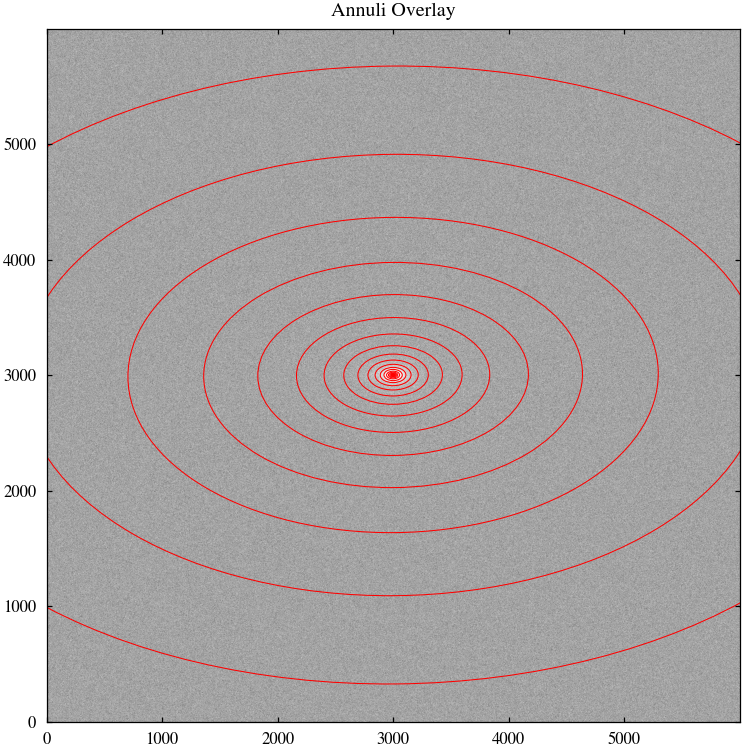

/tmp/ipykernel_1775958/3667420062.py:218: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


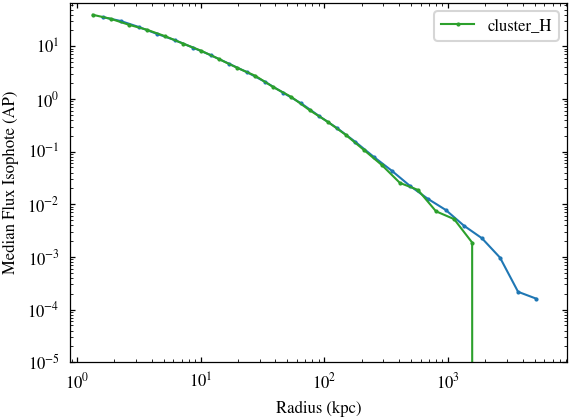

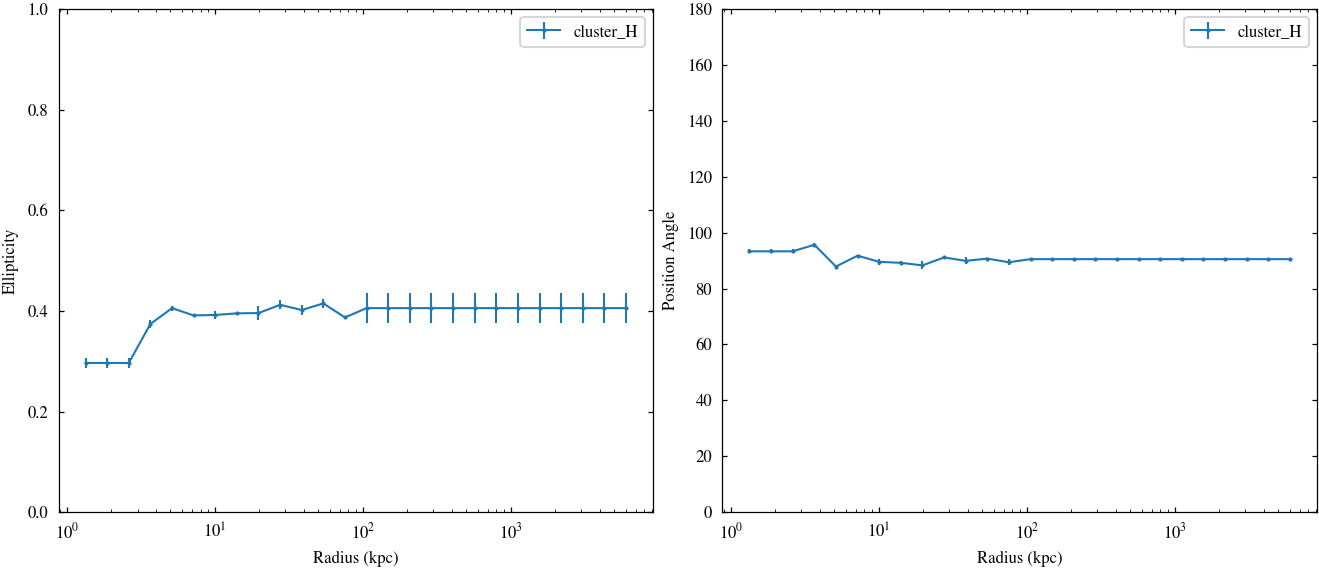

In [82]:
# mock image but no masking is neded, autoprof is running. 

cluster_ids = ["cluster"]
image_dir = Path("/home/ppzjbg/JGM_Tests/Mock_Images/")
outdir = Path("/home/ppztk1/Erosita/Outputs_Clusters/")
filters = ["H"]

process_cluster_pipeline(
    image_dir=image_dir,
    outdir=outdir,
    cluster_ids=cluster_ids,
    filters=filters,
    mock_image=True,
    masking=False,
    rerun_masking = False,
    run_autoprof_function = True, # if .prof files already exist and only SB extraction is needed.
    SB_extraction=True,
    show_profiles = True,
    # prefix = 'no_noise' # to run this on 'no_noise' mock images comment this out.
)

Processing /home/ppzjbg/JGM_Tests/Mock_Images/cluster_H.fits
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
Using existing masks — skipping mask generation.
Saving cleaned mock image from HDU[1]...
Extracting SB profile for cluster in H...
Loaded Autoprof profile /home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/cluster_H_loaded_mask.prof
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


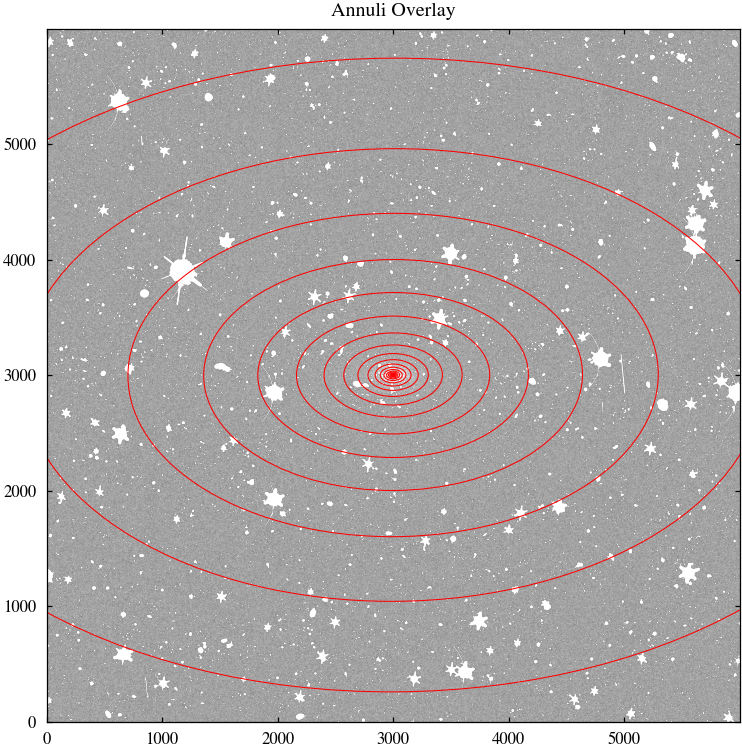

/tmp/ipykernel_1775958/137924547.py:218: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


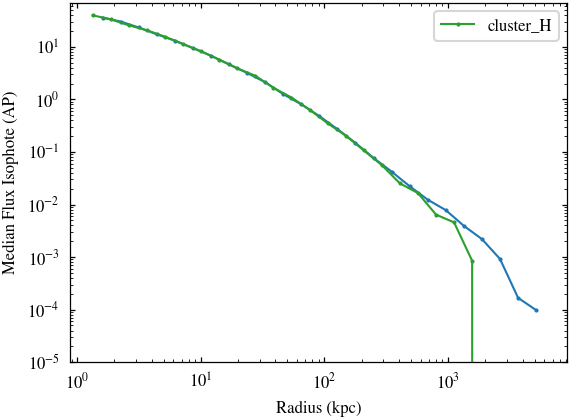

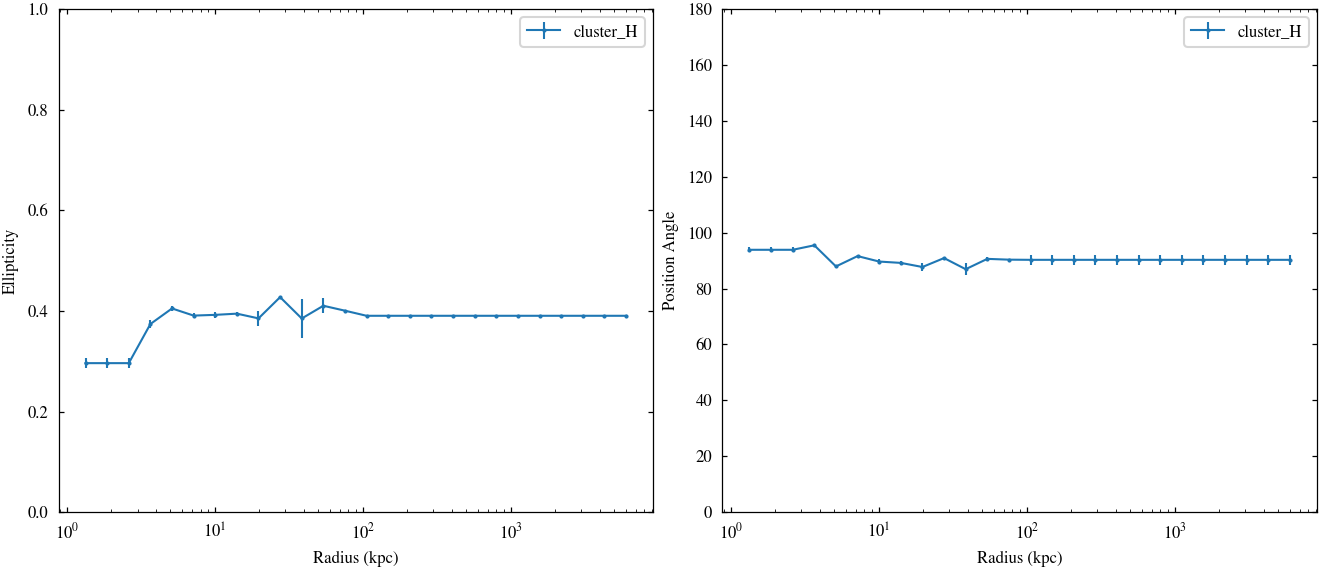

In [86]:
#same mock image but using a mask loaded from a random cluster. So no rerunning the masking procedure.

cluster_ids = ["cluster"]
image_dir = Path("/home/ppzjbg/JGM_Tests/Mock_Images/")
outdir = Path("/home/ppztk1/Erosita/Outputs_Clusters/")
filters = ["H"]

process_cluster_pipeline(
    image_dir=image_dir,
    outdir=outdir,
    cluster_ids=cluster_ids,
    filters=filters,
    mock_image=True,
    masking=True,
    rerun_masking = False,
    run_autoprof_function = True, # if .prof files already exist and only SB extraction is needed.
    SB_extraction=True,
    show_profiles = True,
    prefix2='loaded_mask'
)

Processing /home/ppzjbg/JGM_Tests/Mock_Images/cluster_H_random_field.fits
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
Using existing masks — skipping mask generation.
Saving cleaned mock image from HDU[1]...
cluster_H_random_field: head mask segmentation map at: 0.0 sec
cluster_H_random_field: head background at: 316.5 sec
cluster_H_random_field: head psf at: 332.1 sec
cluster_H_random_field: head center at: 332.1 sec
cluster_H_random_field: head isophoteinit at: 332.9 sec
cluster_H_random_field: head isophotefit at: 334.6 sec
cluster_H_random_field: head isophoteextract at: 337.7 sec
cluster_H_random_field: head writeprof at: 720.0 sec
cluster_H_random_field: Processing Complete! (at 720.0 sec)
AutoProf completed successfully for ['cluster_H_random_field']!
Deleted: fit_ellipse_cluster_H_random_field.jpg
Deleted: phase_profile_cluster_H_random_field.jpg
Deleted: cleaned_cluster_H_random_field.fits
Extracting SB profile for cluster in H...
Loaded Autoprof profile

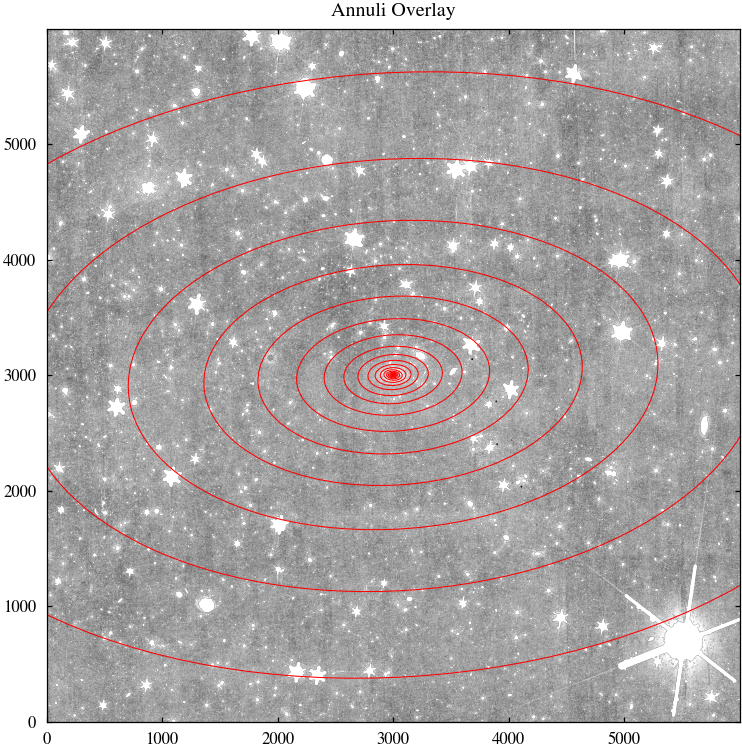

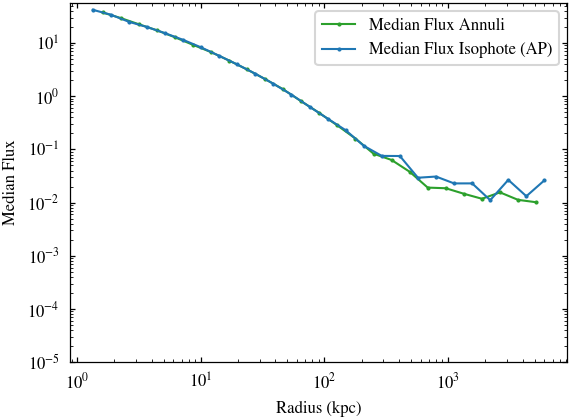

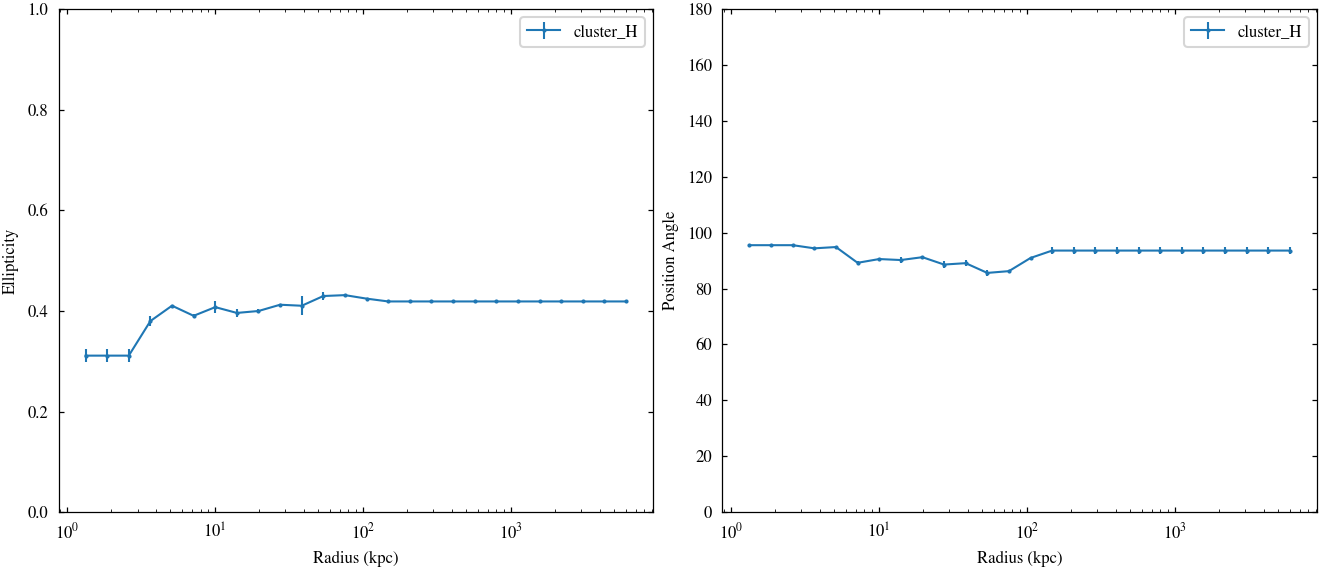

In [94]:
#same mock image but on top of a background with sources, so we will perform masking.

cluster_ids = ["cluster"]
image_dir = Path("/home/ppzjbg/JGM_Tests/Mock_Images/")
outdir = Path("/home/ppztk1/Erosita/Outputs_Clusters/")
filters = ["H"]

process_cluster_pipeline(
    image_dir=image_dir,
    outdir=outdir,
    cluster_ids=cluster_ids,
    filters=filters,
    mock_image=True,
    masking=True,
    rerun_masking=True,
    run_autoprof_function = True, # if .prof files already exist and only SB extraction is needed.
    SB_extraction=True,
    show_profiles = True,
    prefix='random_field'
)

In [ ]:
#same mock image but on top of a background with sources, so we will perform masking.
# Altering faint growth factor

cluster_ids = ["cluster"]
image_dir = Path("/home/ppzjbg/JGM_Tests/Mock_Images/")
outdir = Path("/home/ppztk1/Erosita/Outputs_Clusters/")
filters = ["H"]

process_cluster_pipeline(
    image_dir=image_dir,
    outdir=outdir,
    cluster_ids=cluster_ids,
    filters=filters,
    mock_image=True,
    masking=True,
    rerun_masking=True,
    run_autoprof_function = True, # if .prof files already exist and only SB extraction is needed.
    SB_extraction=True,
    show_profiles = True,
    prefix='random_field',
    prefix2='growth_0.25'
)

Processing /home/ppzjbg/JGM_Tests/Mock_Images/cluster_H_random_field.fits
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
Creating new masks...


2025-04-10 10:49:40 - nicl.mask.create_bcg_mask - INFO - Creating BCG mask
2025-04-10 10:49:49 - nicl.mask.create_icl_mask - INFO - Creating ICL mask
2025-04-10 10:49:49 - nicl.mask.create_icl_mask - DEBUG - Estimating background with box size 300 and filter size 3
2025-04-10 10:50:06 - nicl.mask.create_icl_mask - DEBUG - Average 0.5 sigma detection threshold: 0.01023
2025-04-10 10:50:06 - nicl.mask.create_icl_mask - DEBUG - Smoothing image with sigma=50.0
2025-04-10 10:50:06 - nicl.mask.create_icl_mask - DEBUG - Smoothing with a sampled median filter
2025-04-10 10:50:58 - nicl.mask.create_icl_mask - DEBUG - Detecting sources
2025-04-10 10:51:03 - nicl.mask.create_icl_mask - DEBUG - Keeping segment at specified position
2025-04-10 10:51:08 - nicl.mask.create_icl_mask - DEBUG - Creating source mask with dilation radius 70.0
2025-04-10 10:57:17 - nicl.mask.create_icl_mask - INFO - ICL mask created, 170710 pixels masked (0.47%)
2025-04-10 10:57:17 - nicl.mask.create_object_mask - INFO - C

# Comparing AP profiles to our measurements

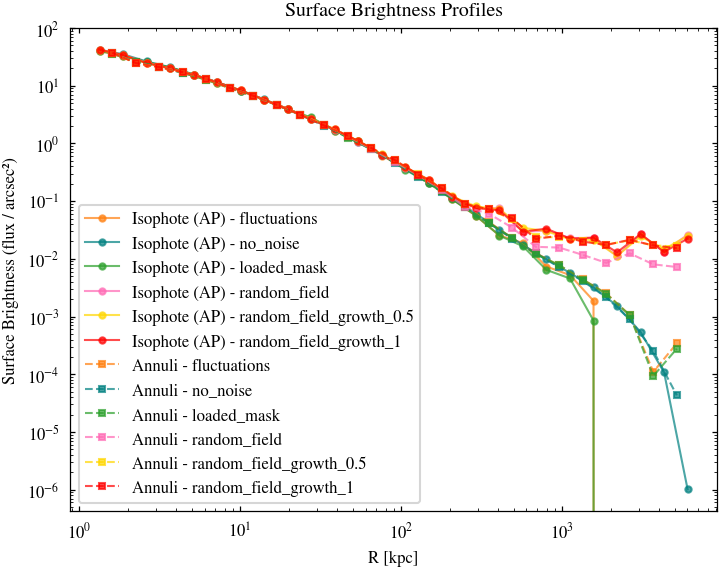

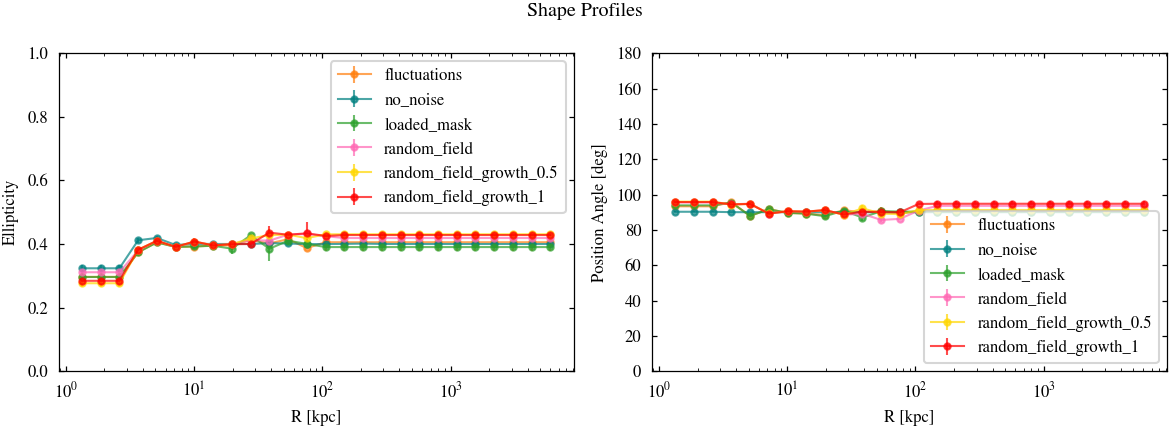

In [34]:
outdir = Path('/home/ppztk1/Erosita/Outputs_Clusters/')
cluster_id = 'cluster'
filter_name = 'H'
prefixes = ["", "no_noise", "loaded_mask", "random_field", "random_field_growth_0.25", "random_field_growth_0.5","random_field_growth_1"]

pixelscale = 0.3  # arcsec/pix
cluster_z = 0.3
arcsec_to_kpc = cosmo.arcsec_per_kpc_proper(cluster_z).value

prefix_colors = {
    "fluctuations": "tab:orange",   # corresponds to "" prefix
    "no_noise": "teal",
    "loaded_mask": "tab:green",
    "random_field": "hotpink",
    "random_field_growth_0.25":"red",
    "random_field_growth_0.5":"gold",
    "random_field_growth_1":"salmon",

}
prof_style = {"linestyle": "-", "marker": "o"}       
meas_style = {"linestyle": "--", "marker": "s"}    


profiles = []      # From .prof files
measurements = []  # From Profile_measurements_*.csv

for prefix in prefixes:
    label = prefix if prefix else "fluctuations"

    prof_file = outdir / cluster_id / "autoprof_results" / f"{cluster_id}_{filter_name}{'_' + prefix if prefix else ''}.prof"
    if prof_file.exists():
        prof = pd.read_csv(prof_file, skiprows=1)
        prof["R_kpc"] = prof["R"] / arcsec_to_kpc
        profiles.append((label, prof))
    else:
        print(f"Profile file not found: {prof_file}")


    meas_file = outdir / cluster_id / (f"Profile_measurements_{prefix}.csv" if prefix else "Profile_measurements.csv")
    if meas_file.exists():
        meas = pd.read_csv(meas_file)
        meas["R_kpc"] = meas["Radial_Bin_Centre_pix"] * pixelscale / arcsec_to_kpc
        measurements.append((label, meas))
    else:
        print(f"Measurement file not found: {meas_file}")

############################# Plotting SB profiles
fig, ax = plt.subplots(figsize=(5, 4))

# AP profile isophote measurements
for label, prof in profiles:
    color = prefix_colors.get(label, "black")
    ax.plot(
        prof["R_kpc"], prof["I"],
        label=f"Isophote (AP) - {label}",
        color=color,
        linestyle=prof_style["linestyle"],
        marker=prof_style["marker"],
        ms=3,
        alpha=0.5
    )

#  annuli measurements
for label, meas in measurements:
    color = prefix_colors.get(label, "black")
    ax.plot(
        meas["R_kpc"], meas["Clipped_median_flux_annulus"],
        label=f"Annuli - {label}",
        color=color,
        linestyle=meas_style["linestyle"],
        marker=meas_style["marker"],
        ms=3,
        alpha=0.5
    )

ax.set_xlabel("R [kpc]")
ax.set_ylabel(r"Surface Brightness (flux / arcsec²)")
ax.set_title("Surface Brightness Profiles")
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_xlim(0,150)
# ax.set_ylim(1,)

ax.legend()
plt.tight_layout()
# plt.savefig(outdir / cluster_id / "SB_profile_comparisons.pdf")

plt.show()

############################ Plotting shape profiles
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharex=True)

for label, prof in profiles:
    color = prefix_colors.get(label, "black")
    ax[0].errorbar(
        prof["R_kpc"], prof["ellip"], yerr=prof["ellip_e"],
        label=label,
        fmt=prof_style["marker"],
        color=color,
        linestyle=prof_style["linestyle"],
        ms=3, alpha=0.7
    )
    ax[1].errorbar(
        prof["R_kpc"], prof["pa"], yerr=prof["pa_e"],
        label=label,
        fmt=prof_style["marker"],
        color=color,
        linestyle=prof_style["linestyle"],
        ms=3, alpha=0.7
    )

ax[0].set_xlabel("R [kpc]")
ax[0].set_ylabel("Ellipticity")
ax[0].set_ylim(0, 1)
ax[0].legend()
ax[0].set_xscale('log')


ax[1].set_xlabel("R [kpc]")
ax[1].set_ylabel("Position Angle [deg]")
ax[1].set_ylim(0, 180)
ax[1].legend()
ax[1].set_xscale('log')

fig.suptitle("Shape Profiles")
plt.tight_layout()
# plt.savefig(outdir / cluster_id / "Shape_comparisons.pdf")
plt.show()


# Example run for a real cluster image with existing mask files

In [95]:
# Erass_table = pd.read_csv('/home/ppztk1/Erosita/erosita_2E14_paper.csv')

# cluster_ids = ["1eRASS J041723.0-474844"]

# image_dir = Path("/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/tutku")
# outdir = Path('/home/ppztk1/Erosita/Outputs_Clusters/')

# filters = ["H"] # can include other bands

# process_cluster_pipeline(
#     image_dir=image_dir,
#     outdir=outdir,
#     cluster_ids=cluster_ids,
#     filters=filters,
#     cluster_info_table=Erass_table,
#     mock_image=False,
#     masking=True,
#     rerun_masking=False,
#     run_autoprof_function = False, # if .prof files already exist and only SB extraction is needed.
#     SB_extraction=True, # set True if masking files wants to be generated or re generated
#     show_profiles = True # if .prof files already exist and only SB extraction is needed.

# )

In [ ]:
# clusterid = "1eRASS J041723.0-474844"
# filter = 'H'
# cluster_dir= f'/home/ppztk1/Erosita/Outputs_Clusters/{clusterid}/'
# image_ccd = CCDData.read(f'/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/tutku/EUC_NIR_W-STK_{filter}-{clusterid}.fits', hdu=1, unit='adu')
# mask_ccd = CCDData.read(f'{cluster_dir}{clusterid}/{clusterid}_{filter}_icl_mask.fits', hdu=0, unit='adu')

# image_data = image_ccd.data
# mask_data = mask_ccd.data
# norm = simple_norm(image_data, 'sqrt', percent=80)

# masked_overlay = np.ma.masked_where(mask_data == 0, mask_data)

# fig, ax = plt.subplots(figsize=(10, 8))
# ax.imshow(image_data, origin='lower', cmap='gray', norm=norm)

# ax.imshow(masked_overlay, origin='lower', cmap='Reds',vmin=0, vmax=1, alpha=0.6)

# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# # ax.set_xlim(2000,4000)
# # ax.set_ylim(2000,4000)
# plt.savefig(cluster_dir+'image_icl_mask_fullsize.pdf')

# # plt.show()
